In [26]:
import pandas as pd
from rapidfuzz import fuzz

movies = pd.read_csv("../data/raw/imdb/title_basics.csv")
movies.set_index('tconst', inplace=True)
movie_dups = pd.read_csv("../data/raw/imdb/title_basics_dups.csv")
acts_in = pd.read_csv("../data/raw/imdb/title_principals.csv")

def calculate_record_similarity(row, records_df):
    """
    Computes a weighted similarity between two records.
    """
    r1 = records_df.loc[row['1']]
    r2 = records_df.loc[row['2']]
    
    # Calculate similarity for specific attributes
    # Using token_set_ratio is often better for ER (handles word reordering)
    title_sim = fuzz.token_set_ratio(r1['primaryTitle'], r2['primaryTitle']) / 100.0
    
    # Simple binary match for year
    year_sim = 1.0 if r1['startYear'] == r2['startYear'] else 0.0
    
    # Weighted average (Adjust weights based on your schema)
    return (title_sim * 0.8) + (year_sim * 0.2)

# 2. Compute similarity for all labeled duplicates
movie_dups['similarity_score'] = movie_dups.apply(
    calculate_record_similarity, 
    axis=1, 
    records_df=movies
)

# 3. Sort ascending to find "Hard Matches" 
# (Items labeled as duplicate but with low string similarity)
hard_matches = movie_dups.sort_values(by='similarity_score', ascending=True)

print("--- Hardest Matches (Low Similarity, but are Duplicates) ---")
for _, row in hard_matches.head(10).iterrows():
    r1 = movies.loc[row['1']]
    r2 = movies.loc[row['2']]
    print(f"Score: {row['similarity_score']:.2f}")
    print(f"  R1: {r1['primaryTitle']} ({r1['startYear']})")
    print(f"  R2: {r2['primaryTitle']} ({r2['startYear']})\n")

--- Hardest Matches (Low Similarity, but are Duplicates) ---
Score: 0.33
  R1: TheEven Money (2011)
  R2: Even Moneyb (2001)

Score: 0.53
  R1: HRi (2006)
  R2: HRg (2004)

Score: 0.60
  R1: Jessiel (2011)
  R2: TheJessie (2012)

Score: 0.62
  R1: TheKoichiro Unos Female Gymnastic Teacher (1987)
  R2: Koichiro Unos Female Gymnastic TeacherO (1979)

Score: 0.62
  R1: TheKoichiro Unos Female Gymnastic Teacher (1987)
  R2: Koichiro Unos Female Gymnastic Teacherv (1977)

Score: 0.62
  R1: TheRoxanne (2004)
  R2: RoxanneZ (2005)

Score: 0.64
  R1: HR (2007)
  R2: HRi (2006)

Score: 0.64
  R1: AmalP (2011)
  R2: Amalp (2016)

Score: 0.64
  R1: TheJessie (2012)
  R2: Jessie (2011)

Score: 0.64
  R1: HR (2006)
  R2: HRg (2004)



In [27]:
import random

def find_hard_non_matches(records_df, duplicates_df, sample_size=1000):
    """
    Finds non-duplicate pairs with high similarity (Hard Non-Matches).
    """
    # 1. Create a set of known duplicates for fast lookup (ground truth)
    # We store both (A, B) and (B, A) to ensure we don't pick them as non-matches
    known_dups = set()
    for _, row in movie_dups.iterrows():
        known_dups.add((row['1'], row['2']))
        known_dups.add((row['2'], row['1']))

    # 2. Blocking: Group by 'year' to find plausible non-match candidates
    # This prevents us from comparing "The Karate Kid" to "Finding Nemo"
    candidates = []
    grouped = movies.groupby('startYear')

    for year, group in grouped:
        if len(group) < 2:
            continue
            
        # Get IDs in this year block
        ids = group.index.tolist()
        
        # Sample pairs within the same year to find "Hard Non-Matches"
        # Increase 'k' if you want a more exhaustive search
        for _ in range(min(len(ids) * 2, 500)): 
            idx1, idx2 = random.sample(ids, 2)
            
            # Only proceed if they are NOT known duplicates
            if (idx1, idx2) not in known_dups:
                candidates.append((idx1, idx2))

    # 3. Calculate similarity for these candidates
    results = []
    for left_id, right_id in candidates[:sample_size]:
        r1 = movies.loc[left_id]
        r2 = movies.loc[right_id]
        
        # Scoring logic
        title_sim = fuzz.token_set_ratio(str(r1['primaryTitle']), str(r2['primaryTitle'])) / 100.0
        
        results.append({
            'left_id': left_id,
            'right_id': right_id,
            'similarity_score': title_sim,
            'left_title': r1['primaryTitle'],
            'right_title': r2['primaryTitle'],
            'year': r1['startYear']
        })

    # 4. Sort descending: High similarity + Not Duplicates = Hard Non-Matches
    hard_non_matches = pd.DataFrame(results).sort_values(by='similarity_score', ascending=False)
    
    return hard_non_matches

# Run the detection
hard_non_matches = find_hard_non_matches(movies, movie_dups)

print("--- Top 10 Hard Non-Matches (High Similarity, but NOT Duplicates) ---")
print(hard_non_matches[['left_title', 'right_title', 'similarity_score']].head(10))

--- Top 10 Hard Non-Matches (High Similarity, but NOT Duplicates) ---
                             left_title  \
897                            The Swap   
920                            The Swap   
199                Bandits of the WestU   
198  Inside the Walls of Folsom PrisonE   
810               The House by the Lake   
948      The Education of Sonny Carsonz   
952                           The Devil   
965      The Education of Sonny Carsonz   
967                           The Devil   
650                          The Devils   

                               right_title  similarity_score  
897  The 36th Annual Golden Globes Awardsm          0.545455  
920  The 36th Annual Golden Globes Awardsm          0.545455  
199     Inside the Walls of Folsom PrisonE          0.518519  
198                   Bandits of the WestU          0.518519  
810       The Golden Claws of the Cat Girl          0.500000  
948                              The Swapq          0.500000  
952            

In [28]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

def evaluate_difficulty(movies_df, junction_df, duplicates_df, top_k=10):
    # 1. Prepare "Flattened" Record Strings for TF-IDF
    # Combine title and any other text features into one string
    # movies_df['combined_text'] = movies_df['primaryTitle'].astype(str) + " " + movies_df.get('genres', '')
    movies_df['combined_text'] = movies_df['primaryTitle'].astype(str) 
    
    tfidf = TfidfVectorizer(stop_words='english', analyzer='char_wb', ngram_range=(3,3))
    tfidf_matrix = tfidf.fit_transform(movies_df['combined_text'])
    
    # 2. Map Neighborhoods (Junction Table: movie_id -> [actor_ids])
    # Assuming junction_df has columns ['movie_id', 'neighbor_id']
    neighborhoods = junction_df.groupby('tconst')['nconst'].apply(set).to_dict()

    # 3. Create Ground Truth Set
    known_dups = set()
    for _, row in duplicates_df.iterrows():
        # Store as sorted tuple to handle (A,B) and (B,A) identically
        pair = tuple(sorted((row['1'], row['2'])))
        known_dups.add(pair)

    results = []
    movie_ids = movies_df.index.tolist()

    # 4. For a sample of movies, find the most similar others
    for i, m1_id in enumerate(movie_ids):
        # Get cosine similarity of this movie against ALL others
        sim_vector = cosine_similarity(tfidf_matrix[i], tfidf_matrix).flatten()
        
        # Get indices of top_k most similar (excluding itself)
        related_indices = sim_vector.argsort()[-(top_k+1):-1][::-1]
        
        for idx in related_indices:
            m2_id = movie_ids[idx]
            
            # --- THE CRITICAL CHECKS ---
            # 1. Identity Check: Skip if it's the same record
            if m1_id == m2_id:
                continue
            
            # 2. Symmetry Check: To avoid (A,B) and (B,A) duplicates in our results,
            # we only process if ID1 < ID2 (lexicographical order)
            if str(m1_id) >= str(m2_id):
                continue
            
            score = sim_vector[idx]
            
            # Neighborhood Jaccard Similarity
            n1 = neighborhoods.get(m1_id, set())
            n2 = neighborhoods.get(m2_id, set())
            
            intersection = len(n1.intersection(n2))
            union = len(n1.union(n2))
            jaccard = intersection / union if union > 0 else 0
            
            is_dup = (m1_id, m2_id) in known_dups or (m2_id, m1_id) in known_dups
            
            results.append({
                'id1': m1_id, 'id2': m2_id,
                'string_sim': score,
                'neighbor_sim': jaccard,
                'is_duplicate': is_dup
            })

    return pd.DataFrame(results)

# Run Analysis
diff_df = evaluate_difficulty(movies, acts_in, movie_dups)

# --- FINDING THE HARD CASES ---

# 1. Hard Matches (Duplicates with low similarity)
hard_matches = diff_df[diff_df['is_duplicate']].sort_values(['string_sim', 'neighbor_sim']).head(30)
display(hard_matches)

# 2. Hard Non-Matches (High similarity, but NOT duplicates)
hard_non_matches = diff_df[~diff_df['is_duplicate']].sort_values('string_sim', ascending=False).head(10)
display(hard_non_matches)

# 3. Neighborhood Conflict (Looks similar, but neighbors are totally different)
neighborhood_conflict = diff_df[(diff_df['string_sim'] > 0.4) & (diff_df['string_sim'] < 0.99)& (diff_df['neighbor_sim'] == 0)].sort_values('string_sim', ascending=False).head(10)
display(neighborhood_conflict)

/opt/anaconda3/envs/deepcem311/lib/python3.11/site-packages/sklearn/feature_extraction/text.py:539: UserWarning: The parameter 'stop_words' will not be used since 'analyzer' != 'word'
  warnings.warn(


,id1,id2,string_sim,neighbor_sim,is_duplicate
2446,tt12545225,tt12545226,0.380648,0.250000,True
10245,tt12545224,tt12545225,0.411854,0.000000,True
11095,tt0933344,tt12545225,0.411854,0.200000,True
10016,tt12531252,tt12531253,0.427966,0.000000,True
10163,tt12531253,tt6103096,0.427966,0.000000,True
10548,tt12531251,tt12531253,0.427966,0.000000,True
10244,tt12545224,tt12545226,0.473743,0.200000,True
11094,tt0933344,tt12545226,0.473743,0.500000,True
6002,tt12532974,tt12532975,0.480858,0.000000,True
5904,tt12541274,tt12541275,0.497622,0.083333,True


,id1,id2,string_sim,neighbor_sim,is_duplicate
6867,tt12539151,tt7941920,0.947616,0.0,False
7282,tt12539152,tt7941920,0.947616,0.0,False
5263,tt12536014,tt2014365,0.947616,0.0,False
5262,tt12536014,tt12539152,0.947616,0.0,False
5261,tt12536014,tt12539153,0.947616,0.0,False
10424,tt2014365,tt7941920,0.947616,0.0,False
11235,tt12539153,tt7941920,0.947616,0.0,False
5264,tt12536014,tt12539151,0.947616,0.0,False
4415,tt1202151,tt1285278,0.790551,0.0,False
13007,tt12541277,tt1285278,0.790551,0.0,False


,id1,id2,string_sim,neighbor_sim,is_duplicate
12921,tt12535275,tt3811966,0.976089,0.0,True
12922,tt12535275,tt12535276,0.976089,0.0,True
6307,tt12537300,tt12537301,0.965181,0.0,True
13408,tt12542408,tt12542410,0.963439,0.0,True
3860,tt12533048,tt12533049,0.961992,0.0,True
10228,tt12531998,tt12531999,0.960621,0.0,True
3117,tt12545610,tt12545611,0.959776,0.0,True
3116,tt12545610,tt2574518,0.959776,0.0,True
10199,tt12545609,tt12545610,0.959776,0.0,True
10053,tt12535537,tt12535538,0.959091,0.0,True


In [ ]:
from collections import defaultdict
import pickle
from typing import List, Set, Tuple

import matplotlib.pyplot as plt
import numpy as np



def calc_sizes(components):

    occs = defaultdict(int)
    comps_indexed_by_size = defaultdict(list)
    for c in components:
        size = len(c)
        occs[size] = occs[size] + 1
        comps_indexed_by_size[size].append(c)
    return occs, comps_indexed_by_size

def plot_binned_sizes(occs):
    bins = {
        "Size 1": 0,
        "Size 2": 0,
        "Size 3-5": 0,
        "Size 6-10": 0,
        "Size 11-50": 0,
        "Size 51+": 0
    }

    for size, count in occs.items():
        if size == 1: bins["Size 1"] += count
        elif size == 2: bins["Size 2"] += count
        elif size <= 5: bins["Size 3-5"] += count
        elif size <= 10: bins["Size 6-10"] += count
        elif size <= 50: bins["Size 11-50"] += count
        else: bins["Size 51+"] += count

    plt.figure(figsize=(10, 6))
    plt.bar(bins.keys(), bins.values(), color='teal')
    plt.xticks(rotation=45)
    plt.ylabel("Number of Components")
    plt.title("Binned Component Size Distribution")
    plt.tight_layout()
    plt.show()

def get_name_movie_dist(comps_indexed_by_size, size):
    for idx, s in enumerate(comps_indexed_by_size[size]):
        

        print(f"For component  with size {size}:")
        print(f"Index {idx}: Amount Names: {nm}, amount movies: {tt}")
        
def plot_size_dist(occs, name):
    sorted_keys = sorted(occs.keys())
    names = [int(k) for k in sorted_keys]
    values = [int(occs[k]) for k in sorted_keys]
    print(names)
    print(values)

    plt.figure(figsize=(10, 5))
        
    # 3. Use bar() with explicit alignment
    plt.bar(names, values, align='center', width=0.8)

    plt.xlabel('Component Size')
    plt.ylabel('Counts')
    plt.title(f"Component Size Distribution {name}")

    plt.show()


# All Components

560
{'i2003', 'a469', 'a13', 'a468', 'a380', '496', '1422', '1577', 'a25', '460', '442', 'a333', 'a14', 'a18', 'a274', '1034', 'a95', 'i1836', '440', '1423', 'a29', '459', '1576', 'i2318', '441', '614'}
{'614', '460', '1423', '442', '496', '1422', '459', '1577', '1576', '1034', '441', '440'}
{'i2003', 'i1836', 'i2318'}
set()
{'a468', 'a25', 'a333', 'a29', 'a380', 'a18', 'a14', 'a274', 'a95', 'a469', 'a13'}
[3, 4, 5]
[63, 334, 163]


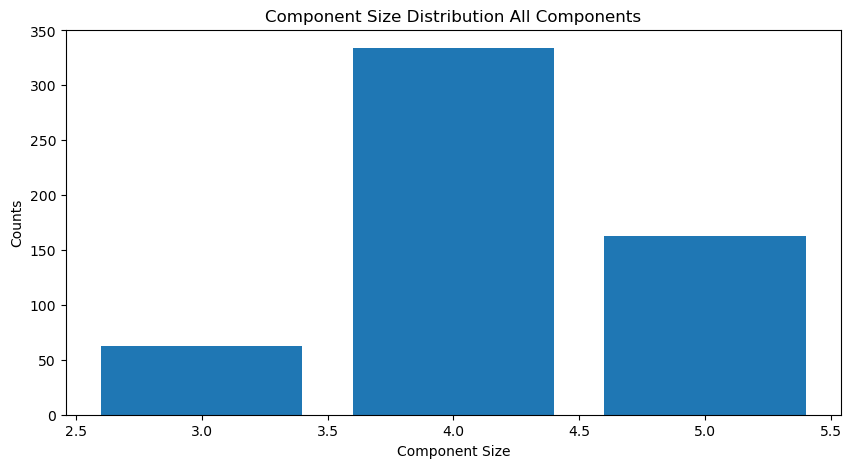

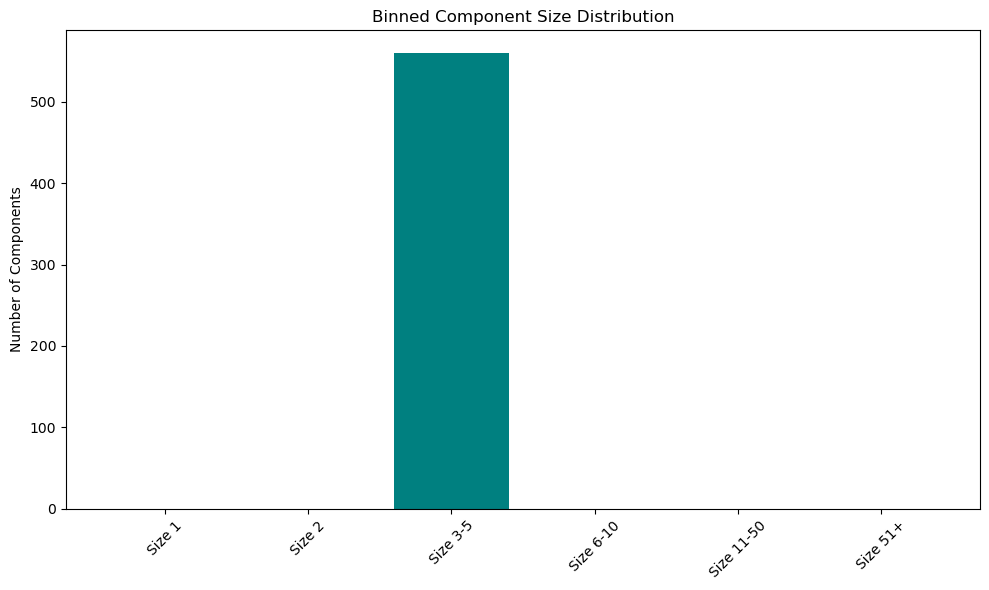

For component  with size 3:
Index 0: Amount Names: 0, amount movies: 0
For component  with size 3:
Index 1: Amount Names: 0, amount movies: 0
For component  with size 3:
Index 2: Amount Names: 0, amount movies: 0
For component  with size 3:
Index 3: Amount Names: 0, amount movies: 0
For component  with size 3:
Index 4: Amount Names: 0, amount movies: 0
For component  with size 3:
Index 5: Amount Names: 0, amount movies: 0
For component  with size 3:
Index 6: Amount Names: 0, amount movies: 0
For component  with size 3:
Index 7: Amount Names: 0, amount movies: 0
For component  with size 3:
Index 8: Amount Names: 0, amount movies: 0
For component  with size 3:
Index 9: Amount Names: 0, amount movies: 0
For component  with size 3:
Index 10: Amount Names: 0, amount movies: 0
For component  with size 3:
Index 11: Amount Names: 0, amount movies: 0
For component  with size 3:
Index 12: Amount Names: 0, amount movies: 0
For component  with size 3:
Index 13: Amount Names: 0, amount movies: 0
Fo

In [35]:
with open('../pickles/pokemon_components.pickle', 'rb') as f:
    components = pickle.load(f)
print(len(components))
# for c in components:
#     print(len(c["all_nodes"]))
component = components[2]

print(component["all_nodes"])
print(component["pokemon"])
print(component["item"])
print(component["move"])
print(component["ability"])
occs, comps_by_size = calc_sizes(components)

plot_size_dist(occs, "All Components")
plot_binned_sizes(occs)
for key in occs.keys(): 
    get_name_movie_dist(comps_by_size, key)


# Per Split

In [31]:
with open('../pickles/splits.pickle', 'rb') as f:
    splits: Tuple[List[Set[str]], List[Set[str]], List[Set[str]]] = pickle.load(f)


## TRAIN

In [23]:

components: list[Set[str]] = splits[0]

print(components)
occs, comps_by_size = calc_sizes(components)

plot_size_dist(occs, "TRAIN SPLIT")
plot_binned_sizes(occs)
for key in occs.keys(): 
    get_name_movie_dist(comps_by_size, key)


NameError: name 'splits' is not defined

## Validation

[{'nm0924502', 'nm6283388', 'nm21965561', 'nm0961594', 'tt3526322', 'nm0671980', 'nm0415529', 'nm1318412', 'tt12541688', 'nm21965564', 'nm1167928', 'nm21965563', 'nm21965562', 'nm6283387', 'tt12541687'}, {'nm0049169', 'tt12545320', 'nm0146720', 'tt12545321', 'nm0056435', 'nm0858253', 'nm21969111', 'nm0127758', 'tt0190244', 'nm0276910', 'nm0195882', 'nm0855892', 'nm0937403', 'nm21969110', 'nm0210460'}, {'nm21959608', 'tt5660288', 'tt12535776', 'tt12535777', 'nm5479763', 'nm6723430', 'nm8967858', 'tt12535775', 'nm4165585', 'nm21959609', 'nm8094541', 'nm8933900', 'nm6723429', 'nm5450947', 'nm7599666'}, {'tt1733527', 'nm2684703', 'nm4099603', 'nm3843001', 'nm21961671', 'tt12537804', 'nm7425663', 'nm7425664', 'nm2762061', 'nm0213255', 'nm7425662', 'nm4162789', 'nm0322219', 'tt12537803'}, {'nm2349698', 'nm21967262', 'nm2707815', 'nm0003984', 'nm0508190', 'nm1252080', 'nm0081906', 'nm21967261', 'tt12543416', 'tt1107906', 'tt12543415', 'nm0634463', 'nm0305380', 'nm1253181'}, {'nm0359642', 'nm0

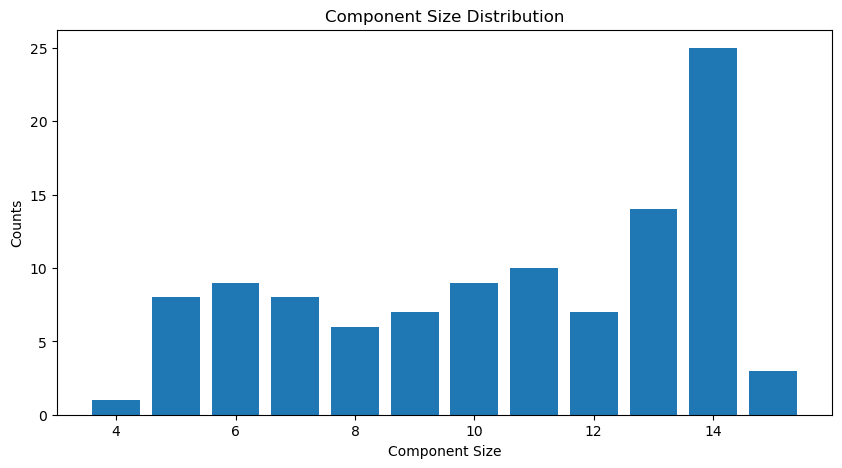

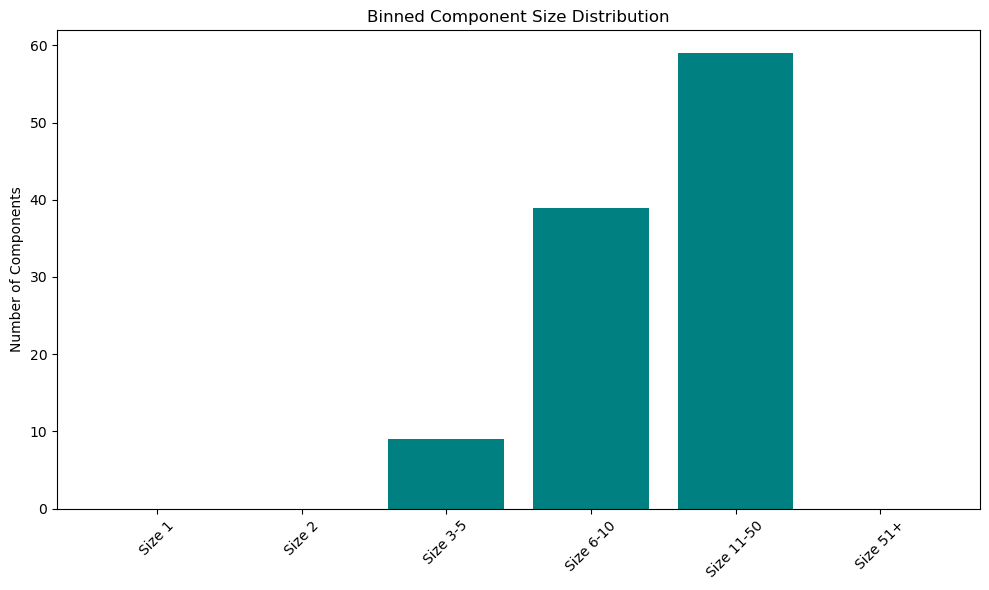

For component  with size 15:
Index 0: Amount Names: 12, amount movies: 3
For component  with size 15:
Index 1: Amount Names: 12, amount movies: 3
For component  with size 15:
Index 2: Amount Names: 11, amount movies: 4
For component  with size 14:
Index 0: Amount Names: 11, amount movies: 3
For component  with size 14:
Index 1: Amount Names: 11, amount movies: 3
For component  with size 14:
Index 2: Amount Names: 11, amount movies: 3
For component  with size 14:
Index 3: Amount Names: 11, amount movies: 3
For component  with size 14:
Index 4: Amount Names: 11, amount movies: 3
For component  with size 14:
Index 5: Amount Names: 11, amount movies: 3
For component  with size 14:
Index 6: Amount Names: 11, amount movies: 3
For component  with size 14:
Index 7: Amount Names: 11, amount movies: 3
For component  with size 14:
Index 8: Amount Names: 10, amount movies: 4
For component  with size 14:
Index 9: Amount Names: 11, amount movies: 3
For component  with size 14:
Index 10: Amount Names

In [33]:
components: list[Set[str]] = splits[1]

print(components)
occs, comps_by_size = calc_sizes(components)

plot_size_dist(occs, "VALIDATION SPLIT")
plot_binned_sizes(occs)
for key in occs.keys(): 
    get_name_movie_dist(comps_by_size, key)


## Test

[{'nm21969008', 'nm0000856', 'nm0105462', 'nm0896533', 'tt12545207', 'nm0918659', 'nm0004864', 'nm21969007', 'tt0043680', 'nm0861703', 'nm0113284', 'nm21969006', 'tt12545208', 'nm0000011', 'nm0366942', 'nm0836328'}, {'nm1403157', 'tt12542324', 'nm21966190', 'tt1047812', 'tt12542322', 'nm21966192', 'nm2677223', 'nm21966193', 'nm21966191', 'nm2677225', 'nm1473037', 'nm21966194', 'nm2679277', 'nm0736835', 'tt12542323', 'nm2679040'}, {'tt12545897', 'nm5646885', 'nm0628582', 'nm1065164', 'tt2873162', 'nm5646884', 'nm3827667', 'nm21969721', 'nm5471006', 'tt12545898', 'nm21969722', 'nm1769926', 'nm2641657', 'nm21969723', 'nm3251402', 'nm3606084'}, {'tt12533225', 'tt7203520', 'nm10137242', 'nm0436722', 'nm0826611', 'nm3626485', 'nm3423765', 'nm21957050', 'nm3655117', 'nm8466651', 'nm2039344', 'nm3008762', 'nm0343322', 'tt12533226', 'nm21957051', 'tt12533224'}, {'nm6302140', 'nm21957040', 'nm4159008', 'nm21957041', 'nm4796384', 'nm9614890', 'nm6403597', 'nm2201887', 'nm21957042', 'tt12533220', 

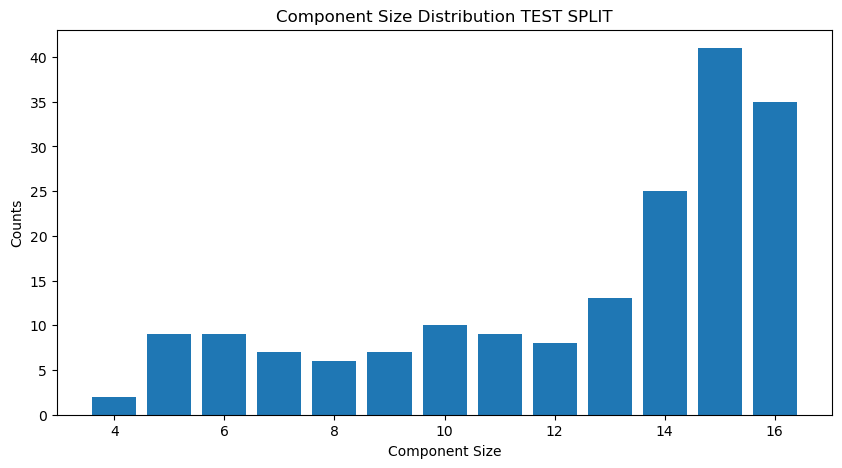

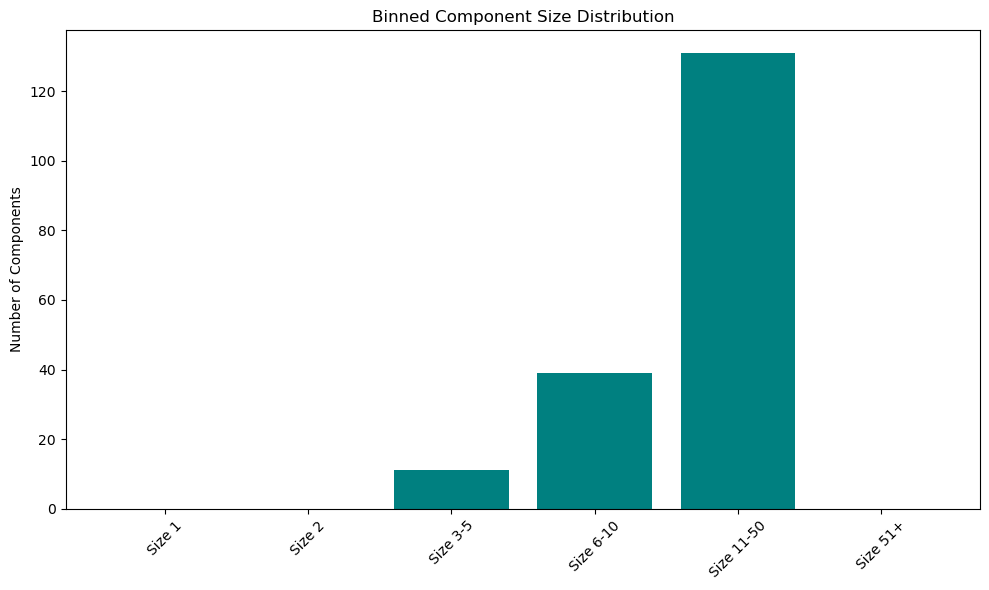

For component  with size 16:
Index 0: Amount Names: 13, amount movies: 3
For component  with size 16:
Index 1: Amount Names: 12, amount movies: 4
For component  with size 16:
Index 2: Amount Names: 13, amount movies: 3
For component  with size 16:
Index 3: Amount Names: 12, amount movies: 4
For component  with size 16:
Index 4: Amount Names: 13, amount movies: 3
For component  with size 16:
Index 5: Amount Names: 13, amount movies: 3
For component  with size 16:
Index 6: Amount Names: 13, amount movies: 3
For component  with size 16:
Index 7: Amount Names: 13, amount movies: 3
For component  with size 16:
Index 8: Amount Names: 13, amount movies: 3
For component  with size 16:
Index 9: Amount Names: 13, amount movies: 3
For component  with size 16:
Index 10: Amount Names: 12, amount movies: 4
For component  with size 16:
Index 11: Amount Names: 13, amount movies: 3
For component  with size 16:
Index 12: Amount Names: 12, amount movies: 4
For component  with size 16:
Index 13: Amount Na

In [39]:
components: list[Set[str]] = splits[2]

print(components)
occs, comps_by_size = calc_sizes(components)

plot_size_dist(occs, "TEST SPLIT")
plot_binned_sizes(occs)
for key in occs.keys(): 
    get_name_movie_dist(comps_by_size, key)


In [2]:
with open('../pickles/pokemon_stats.pickle', 'rb') as f:
    df_stats: pd.DataFrame = pickle.load(f)

df_stats['total_nodes'].describe()

NameError: name 'pickle' is not defined

In [41]:
CONFIGS = ["movie", "name"]
df_stats[[f"{c}_nodes" for c in CONFIGS]].sum()

movie_nodes    2822
name_nodes     8446
dtype: int64

In [47]:
# Duplicate Density
# High Ratio -> Duplicate heavy. 
round(float(df_stats['movie_dupe_count'].sum() / df_stats['movie_nodes'].sum()),2)

0.72